#TreeSHAP Demo with Random Forest

**Dataset:** Breast Cancer Wisconsin Original  
**Model:** Random Forest  
**Goal:** dùng TreeSHAP, đọc các SHAP plots và nhận biết các giới hạn quan trọng.

## 1. Data and Random Forest

In [1]:
!pip -q install shap==0.52.0 ucimlrepo

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

RANDOM_STATE = 42

print("SHAP version:", shap.__version__)

d:\Anaconda\envs\aio2026_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.52.0


### 1.1 Load and prepare data

In [3]:
dataset = fetch_ucirepo(id=15)

X = dataset.data.features.copy()
y = dataset.data.targets.squeeze().copy()

X = X.apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(y, errors="coerce").map({2: 0, 4: 1})

df = X.copy()
df["target"] = y
df = df.dropna().reset_index(drop=True)

X = df.drop(columns="target")
y = df["target"].astype(int)

print("Data shape:", X.shape)
print("Class 0 = Benign")
print("Class 1 = Malignant")
display(X.head())

Data shape: (683, 9)
Class 0 = Benign
Class 1 = Malignant


,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses
0,5,1,1,1,2,1.0,3,1,1
1,5,4,4,5,7,10.0,3,2,1
2,3,1,1,1,2,2.0,3,1,1
3,6,8,8,1,3,4.0,3,7,1
4,4,1,1,3,2,1.0,3,1,1


### 1.2 Train Random Forest

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=2,
    random_state=RANDOM_STATE
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC AUC:  {roc_auc_score(y_test, y_prob):.4f}")

Accuracy: 0.9635
ROC AUC:  0.9855


## 2. Explain the Random Forest with TreeSHAP

TreeSHAP được thiết kế riêng cho mô hình cây.

Trong bài thực hành này, ta giải thích:

$$P(\text{Malignant} \mid x)$$

và dùng một tập background nhỏ để xác định baseline.

### 2.1 TreeExplainer parameters

```python
shap.TreeExplainer(
    model,
    data=None,
    model_output="raw",
    feature_perturbation="auto",
    feature_names=None
)
```

| Tham số | Vai trò |
|---|---|
| `model` | Tree model cần giải thích |
| `data` | Background data dùng để xác định reference distribution |
| `feature_perturbation` | Quy định cách xử lý feature bị xem là missing |
| `model_output` | Chọn output space cần giải thích |
| `feature_names` | Tên feature nếu input không tự chứa tên |
| `approximate` | Không nên đặt trong constructor. Nếu cần approximation thì dùng lúc tính SHAP values |
| `link`, `linearize_link` | Tham số nâng cao để xử lý phép biến đổi output. Bài thực hành này không cần dùng |

Với SHAP `0.52.0`, giá trị mặc định của `feature_perturbation` là **`"auto"`**.

### 2.2 How `feature_perturbation` works

SHAP cần tính giá trị của một coalition:

$$
v(S)
=
E[f(x_S, X_{\bar S})]
$$

Các feature trong $S$ được giữ từ sample đang giải thích. Các feature còn lại được xem là **missing**.

feature_perturbation quy định cách xử lí các missing features.

#### `interventional`

Cần truyền `data=background`.

Cơ chế trực quan:

1. Giữ các feature trong coalition từ sample đang giải thích
2. Lấy các feature còn thiếu từ từng sample trong background
3. Tạo các hybrid samples
4. Cho model predict các hybrid samples
5. Lấy trung bình để ước lượng $v(S)$

```text
Sample cần giải thích
        +
Background samples
        ↓
Hybrid samples
        ↓
Random Forest
        ↓
Average prediction
        ↓
Coalition value
```

Cách này có thể tạo ra tổ hợp feature không thường xuất hiện cùng nhau khi các feature tương quan mạnh.

Runtime tăng theo kích thước background. SHAP documentation gợi ý khoảng 100 đến 1000 background samples cho nhiều bài toán.

#### `tree_path_dependent`

Không cần truyền background riêng.

TreeSHAP dùng số lượng training samples đã đi qua các path trong từng tree. Thông tin này được lưu trong model.

Khi feature tại một split bị missing:

1. Không chọn duy nhất left hoặc right
2. Đi xuống cả hai nhánh
3. Gán trọng số theo số training samples đã đi qua mỗi nhánh
4. Tiếp tục cho đến leaf
5. Kết hợp các leaf values theo trọng số

```text
Missing split feature
        ↓
   ┌────┴────┐
   ↓         ↓
 Left       Right
 weight     weight
   ↓         ↓
 leaf       leaf
   └────┬────┘
        ↓
 weighted value
```

#### `auto`

Đây là mặc định hiện tại.

```text
data được cung cấp
        ↓
interventional

không có data
        ↓
tree_path_dependent
```

Vì phần này này truyền `data=background`, nếu bỏ dòng:

```python
feature_perturbation="interventional"
```

thì `auto` vẫn chọn `interventional`.

In [5]:
background = X_train.sample(
    n=min(100, len(X_train)),
    random_state=RANDOM_STATE
)

auto_with_background = shap.TreeExplainer(
    model,
    data=background
)

auto_without_background = shap.TreeExplainer(
    model
)

print(
    "Auto with background:",
    auto_with_background.feature_perturbation
)

print(
    "Auto without background:",
    auto_without_background.feature_perturbation
)

Auto with background: interventional
Auto without background: tree_path_dependent


### 2.3 `model_output` and explanation options

`model_output` quyết định **đại lượng mà SHAP values sẽ cộng lại để giải thích**.

| `model_output` | Giải thích gì |
|---|---|
| `"raw"` | Output gốc của tree model. Ý nghĩa phụ thuộc loại model |
| `"probability"` | Probability output. SHAP values cộng với baseline sẽ ra probability |
| `"log_loss"` | Log loss của từng sample. Hữu ích khi phân tích lỗi model |
| Tên method | Có thể giải thích một method được hỗ trợ như `predict_proba` |

`"probability"` và `"log_loss"` hiện chỉ được hỗ trợ với `feature_perturbation="interventional"`.

Trong phần này ta chọn:

```python
model_output="probability"
```

vì muốn giải thích trực tiếp:

$$
P(\text{Malignant} \mid x)
$$

#### Khi tính SHAP values

Hai option quan trọng khác là:

**`approximate=False`**

Mặc định dùng TreeSHAP chính xác. Nếu đặt `True`, SHAP dùng approximation nhanh hơn nhưng không còn đầy đủ các consistency guarantees của Shapley values.

**`check_additivity=True`**

Kiểm tra xem:

$$
\text{Baseline}
+
\sum_i \phi_i
$$

có khớp với model output hay không bằng cách chạy thực nghiệm ở phần sau.

### 2.4 Create the TreeExplainer

In [6]:
tree_explainer = shap.TreeExplainer(
    model,
    data=background,
    feature_perturbation="interventional",
    model_output="probability"
)

all_explanations = tree_explainer(
    X_test,
    approximate=False
)

# RandomForestClassifier has one output for each class
shap_values = all_explanations[:, :, 1]

print("Perturbation:", tree_explainer.feature_perturbation)
print("Model output:", tree_explainer.model_output)
print("SHAP shape:", shap_values.shape)

Perturbation: interventional
Model output: probability
SHAP shape: (137, 9)


### 2.5 Check the additive explanation

TreeSHAP phân rã prediction thành:

$$
\text{Prediction}
=
\text{Baseline}
+
\sum_i \text{SHAP}_i
$$

In [7]:
reconstructed = (
    shap_values.base_values
    + shap_values.values.sum(axis=1)
)

check = pd.DataFrame({
    "Model probability": y_prob,
    "Baseline + SHAP": reconstructed,
    "Difference": np.abs(y_prob - reconstructed)
})

display(check.head())
print("Maximum difference:", check["Difference"].max())

,Model probability,Baseline + SHAP,Difference
0,0.000463,0.000463,1.004215e-08
1,0.000584,0.000584,9.702633e-09
2,0.024910,0.024910,8.303907e-09
3,0.000921,0.000921,9.528196e-09
4,0.000463,0.000463,1.007645e-08


Maximum difference: 1.8788004596537178e-08


## 3. Why TreeSHAP

Ta so sánh hai cách giải thích cùng một Random Forest:
- **Exact SHAP** tính chính xác SHAP values nhưng không tận dụng cấu trúc riêng của cây
- **TreeSHAP** tận dụng cấu trúc cây để tính cùng đại lượng hiệu quả hơn

In [8]:
benchmark_background = X_train.sample(
    n=min(30, len(X_train)),
    random_state=RANDOM_STATE
)

def predict_malignant(data):
    data = pd.DataFrame(data, columns=X.columns)
    return model.predict_proba(data)[:, 1]

exact_explainer = shap.ExactExplainer(
    predict_malignant,
    benchmark_background
)

tree_benchmark_explainer = shap.TreeExplainer(
    model,
    data=benchmark_background,
    feature_perturbation="interventional",
    model_output="probability"
)

### 3.1 Runtime comparison

In [9]:
benchmark_sizes = [1, 5, 10]
results = []

# Small warm-up
_ = tree_benchmark_explainer(X_test.iloc[:1])
_ = exact_explainer(
    X_test.iloc[:1],
    silent=True
)

for n in benchmark_sizes:
    X_batch = X_test.iloc[:n]

    start = time.perf_counter()
    _ = tree_benchmark_explainer(X_batch)
    tree_time = time.perf_counter() - start

    start = time.perf_counter()
    _ = exact_explainer(
        X_batch,
        silent=True
    )
    exact_time = time.perf_counter() - start

    results.append({
        "Samples": n,
        "TreeSHAP time (s)": tree_time,
        "Exact SHAP time (s)": exact_time,
        "Speedup": exact_time / tree_time
    })

runtime_df = pd.DataFrame(results)
display(runtime_df.round(4))

,Samples,TreeSHAP time (s),Exact SHAP time (s),Speedup
0,1,0.0132,0.1302,9.8506
1,5,0.0486,4.5809,94.1926
2,10,0.0932,2.1220,22.7590


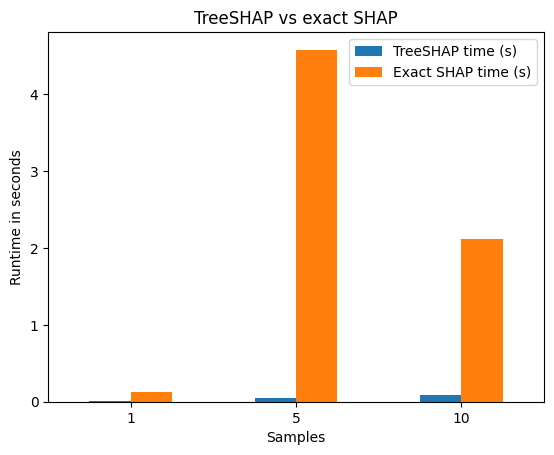

In [10]:
plot_df = runtime_df.set_index("Samples")[
    ["TreeSHAP time (s)", "Exact SHAP time (s)"]
]

plot_df.plot(kind="bar")
plt.ylabel("Runtime in seconds")
plt.title("TreeSHAP vs exact SHAP")
plt.xticks(rotation=0)
plt.show()

**Cách đọc**

- Cột thấp hơn nghĩa là chạy nhanh hơn
- So sánh trên cùng model và cùng số sample
- exact SHAP ở đây là phương pháp tổng quát
- TreeSHAP được tối ưu riêng cho tree models

## 4. Reading SHAP Plots

### 4.1 From SHAP Values to Plots

TreeSHAP đã tính SHAP value cho mỗi feature của mỗi sample:

$$
\phi_{ij}
=
\text{SHAP value của feature } j
\text{ trên sample } i
$$

| Plot | Dữ liệu chính | Ý nghĩa |
|---|---|---|
| Waterfall | Một sample | Baseline cộng từng SHAP contribution |
| Bar | Nhiều sample | Mean absolute SHAP |
| Beeswarm | Nhiều sample | Phân bố SHAP của từng feature |
| Scatter | Một feature | Feature value so với SHAP value |

### 4.2 Waterfall plot

Với một sample:

$$
f(x)
=
\phi_0
+
\sum_j \phi_j
$$

Trong đó $\phi_0$ là baseline và $\phi_j$ là contribution của từng feature.

True label: 1
P(Malignant): 0.9798


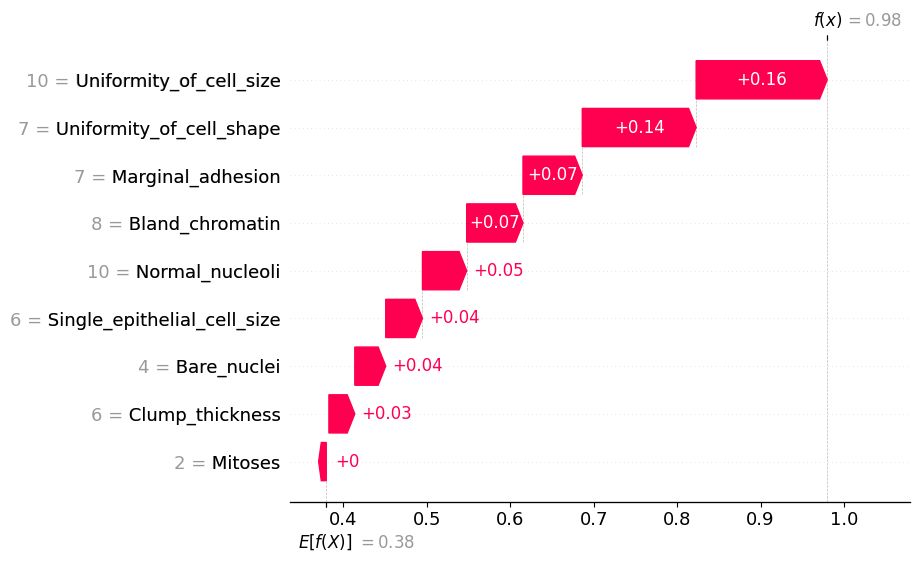

In [11]:
malignant_candidates = np.where(y_prob >= 0.5)[0]
sample_idx = int(malignant_candidates[0]) if len(malignant_candidates) > 0 else 0

print("True label:", int(y_test.iloc[sample_idx]))
print(f"P(Malignant): {y_prob[sample_idx]:.4f}")

shap.plots.waterfall(
    shap_values[sample_idx],
    max_display=len(X.columns)
)

**Cách đọc**

- Bắt đầu từ **baseline**
- Feature có SHAP dương đẩy prediction về phía Malignant
- Feature có SHAP âm kéo prediction về phía Benign
- Thanh dài hơn nghĩa là ảnh hưởng mạnh hơn
- Cuối cùng ta đến prediction của sample

### 4.3 Bar plot

Global importance của feature $j$ được tính bằng mean absolute SHAP:

$$
I_j
=
\frac{1}{N}
\sum_{i=1}^{N}
|\phi_{ij}|
$$

In [12]:
manual_importance = np.abs(shap_values.values).mean(axis=0)

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Mean absolute SHAP": manual_importance
}).sort_values(
    "Mean absolute SHAP",
    ascending=False
)

display(importance_df)

,Feature,Mean absolute SHAP
5,Bare_nuclei,0.100444
1,Uniformity_of_cell_size,0.091415
2,Uniformity_of_cell_shape,0.083278
0,Clump_thickness,0.043150
6,Bland_chromatin,0.037888
3,Marginal_adhesion,0.033690
7,Normal_nucleoli,0.028517
4,Single_epithelial_cell_size,0.024457
8,Mitoses,0.006182


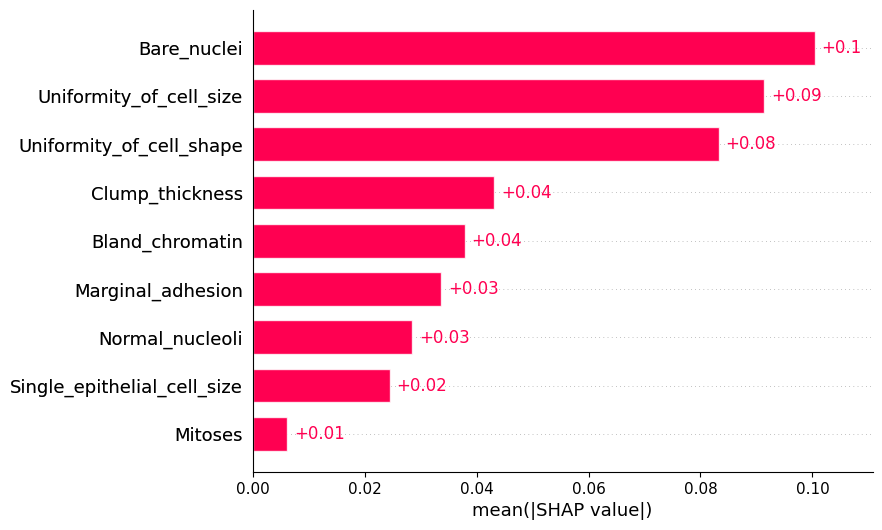

In [13]:
shap.plots.bar(
    shap_values,
    max_display=len(X.columns)
)

**Cách đọc**

- Đây là mức độ quan trọng toàn cục
- Feature ở trên thường có mean absolute SHAP lớn hơn
- Thanh dài nghĩa là feature thường ảnh hưởng mạnh đến prediction
- Bar plot không cho biết hướng tăng hay giảm

### 4.4 Beeswarm plot

Với một feature $j$, beeswarm vẽ các SHAP values:

$$
\phi_{1j},\phi_{2j},\ldots,\phi_{Nj}
$$

Mỗi chấm là một sample. Màu của chấm lấy từ feature value gốc.

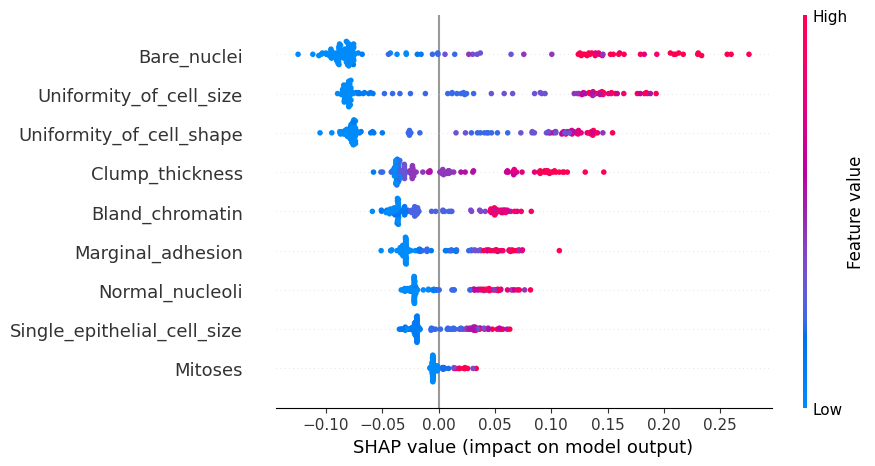

In [14]:
shap.plots.beeswarm(
    shap_values,
    max_display=len(X.columns)
)

**Cách đọc**

- Mỗi chấm là một sample
- Bên phải 0 làm tăng xác suất Malignant
- Bên trái 0 làm giảm xác suất Malignant
- Màu thể hiện giá trị feature cao hay thấp
- Feature phía trên thường quan trọng hơn

### 4.5 Scatter plot

Với feature $j$, mỗi sample tạo một điểm:

$$
(x_{ij},\phi_{ij})
$$

Trục X là feature value và trục Y là SHAP value của feature đó.

Selected feature: Bare_nuclei


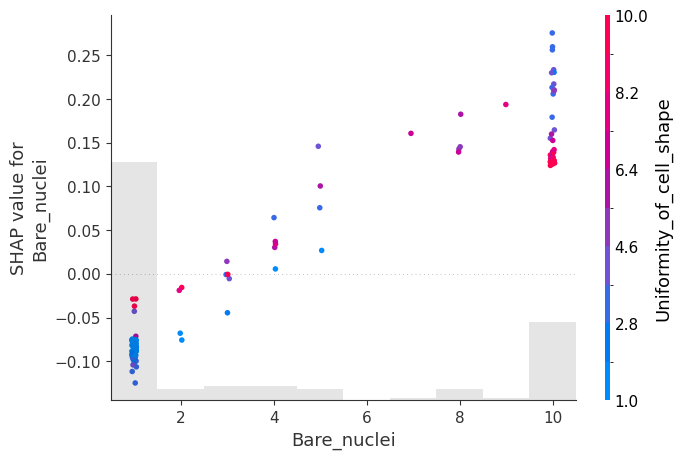

In [15]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
top_feature = X.columns[np.argmax(mean_abs_shap)]

print("Selected feature:", top_feature)

shap.plots.scatter(
    shap_values[:, top_feature],
    color=shap_values
)

**Cách đọc**

- Trục X là giá trị thật của feature
- Trục Y là SHAP value của feature đó
- SHAP dương nghĩa là feature đang đẩy prediction về phía Malignant
- Quan sát hình dạng để thấy model phản ứng thế nào khi feature thay đổi
- Màu giúp gợi ý interaction với feature khác

## 5. Important Limitations and Best Practices

SHAP rất hữu ích để giải thích prediction, nhưng các giá trị SHAP cần được đọc đúng ngữ cảnh.

Trước khi đi vào ba limitation chính, ta sẽ so sánh **feature importance có sẵn trong Random Forest** với **global SHAP importance**. Hai cách đều dùng để xem feature nào quan trọng, nhưng chúng trả lời hai câu hỏi khác nhau.


### 5.1 Random Forest Feature Importance vs SHAP Importance

Random Forest có sẵn:

```python
model.feature_importances_
```

Giá trị này đo mức độ một feature được các cây sử dụng để **giảm impurity** trong quá trình training. Đây là một dạng **global importance của chính tree model**.

Trong khi đó, global SHAP importance thường được tính bằng:

$$
I_j = \frac{1}{N}\sum_{i=1}^{N} |\phi_{ij}|
$$

Nó đo trung bình feature $j$ làm prediction thay đổi mạnh đến đâu trên các sample đang được giải thích.

Ta đặt hai loại importance cạnh nhau để so sánh.


In [16]:
rf_importance = model.feature_importances_
shap_importance = np.abs(shap_values.values).mean(axis=0)

importance_comparison = pd.DataFrame({
    "Feature": X.columns,
    "Random Forest importance": rf_importance,
    "Mean absolute SHAP": shap_importance
})

importance_comparison["RF rank"] = (
    importance_comparison["Random Forest importance"]
    .rank(method="min", ascending=False)
    .astype(int)
)

importance_comparison["SHAP rank"] = (
    importance_comparison["Mean absolute SHAP"]
    .rank(method="min", ascending=False)
    .astype(int)
)

importance_comparison = importance_comparison.sort_values(
    "SHAP rank"
).reset_index(drop=True)

display(importance_comparison.round(4))


,Feature,Random Forest importance,Mean absolute SHAP,RF rank,SHAP rank
0,Bare_nuclei,0.1891,0.1004,3,1
1,Uniformity_of_cell_size,0.2552,0.0914,2,2
2,Uniformity_of_cell_shape,0.2755,0.0833,1,3
3,Clump_thickness,0.0391,0.0432,7,4
4,Bland_chromatin,0.0646,0.0379,5,5
5,Marginal_adhesion,0.0307,0.0337,8,6
6,Normal_nucleoli,0.0480,0.0285,6,7
7,Single_epithelial_cell_size,0.0922,0.0245,4,8
8,Mitoses,0.0055,0.0062,9,9


**Giải thích kết quả**

Hai ranking có thể khá giống nhau ở các feature quan trọng nhất, nhưng **không nhất thiết phải có cùng thứ tự**.

Điều này không có nghĩa một trong hai cách bị sai.

- **Random Forest importance** hỏi: *Feature này được các tree sử dụng nhiều và hữu ích đến đâu khi tạo split?*
- **SHAP importance** hỏi: *Trên các sample đang xét, feature này trung bình làm prediction thay đổi mạnh đến đâu so với baseline?*

Vì câu hỏi khác nhau nên ranking có thể khác nhau.

**Best practice ngắn gọn**

- Dùng `feature_importances_` khi cần một cái nhìn nhanh về model
- Dùng SHAP khi cần giải thích prediction và muốn đi từ global importance xuống từng sample
- Khi báo cáo kết quả, nên nói rõ đang dùng loại feature importance nào
- Không nên so sánh trực tiếp độ lớn của hai cột vì chúng được tính theo hai cách khác nhau


### 5.2 Limitation 1: Correlated Features

Ở bar plot hoặc beeswarm plot, mỗi feature được hiển thị như một feature riêng biệt.

Nhưng nếu hai feature mang thông tin rất giống nhau, model có thể sử dụng chúng gần như thay thế cho nhau. Khi đó, việc hỏi chính xác *feature nào đóng góp bao nhiêu* trở nên khó hơn.

Trước tiên, ta kiểm tra các cặp feature có correlation cao nhất trong training data.


In [17]:
corr = X_train.corr().abs()

pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
    .reset_index()
)

pairs.columns = ["Feature 1", "Feature 2", "Absolute correlation"]

display(pairs.head(10))

,Feature 1,Feature 2,Absolute correlation
0,Uniformity_of_cell_size,Uniformity_of_cell_shape,0.910567
1,Uniformity_of_cell_size,Bland_chromatin,0.739621
2,Uniformity_of_cell_shape,Bare_nuclei,0.738777
3,Uniformity_of_cell_size,Single_epithelial_cell_size,0.732124
4,Uniformity_of_cell_shape,Bland_chromatin,0.718386
5,Uniformity_of_cell_size,Bare_nuclei,0.714484
6,Uniformity_of_cell_shape,Single_epithelial_cell_size,0.713021
7,Uniformity_of_cell_size,Marginal_adhesion,0.711731
8,Uniformity_of_cell_shape,Normal_nucleoli,0.707376
9,Uniformity_of_cell_size,Normal_nucleoli,0.706676


**Giải thích kết quả**

Trong kết quả trên, `Uniformity_of_cell_size` và `Uniformity_of_cell_shape` có correlation khoảng **0.91**.

Điều này có nghĩa là hai feature này thường thay đổi cùng nhau. Khi một feature có giá trị cao, feature còn lại cũng thường có giá trị cao.

Vì chúng chứa nhiều thông tin giống nhau, model có thể dùng một feature để thay thế một phần cho feature còn lại. SHAP sau đó phải **phân chia contribution** giữa chúng.

Do đó, nếu một feature có SHAP importance cao hơn feature kia, ta không nên vội kết luận rằng nó quan trọng hơn một cách hoàn toàn độc lập.

Với `interventional` SHAP, feature bị thiếu được tích phân theo background data. Khi các feature tương quan mạnh, quá trình này đôi khi có thể tạo ra các combination ít gặp trong dữ liệu thật.

**Điểm cần nhớ**

> Khi các feature có correlation cao, nên đọc SHAP values của chúng một cách thận trọng và xem chúng như một nhóm thông tin có liên quan.


### 5.3 Limitation 2: Baseline Matters

SHAP không chỉ hỏi:

> Feature này đóng góp bao nhiêu?

Mà chính xác hơn là:

> Feature này làm prediction thay đổi bao nhiêu **so với một reference population**?

Vì vậy, background dataset quyết định baseline và cũng quyết định câu hỏi mà SHAP đang trả lời.

Ta lấy **cùng một sample** và giải thích nó bằng hai reference population khác nhau:

1. Toàn bộ training data
2. Chỉ các sample Benign


In [18]:
overall_background = X_train.sample(
    n=min(80, len(X_train)),
    random_state=RANDOM_STATE
)

benign_train = X_train[y_train == 0]

benign_background = benign_train.sample(
    n=min(80, len(benign_train)),
    random_state=RANDOM_STATE
)

overall_explainer = shap.TreeExplainer(
    model,
    data=overall_background,
    feature_perturbation="interventional",
    model_output="probability"
)

benign_explainer = shap.TreeExplainer(
    model,
    data=benign_background,
    feature_perturbation="interventional",
    model_output="probability"
)

sample = X_test.iloc[[sample_idx]]

overall_exp = overall_explainer(sample)[:, :, 1][0]
benign_exp = benign_explainer(sample)[:, :, 1][0]

baseline_df = pd.DataFrame({
    "Reference": ["Overall training data", "Benign training data"],
    "Baseline": [
        overall_exp.base_values,
        benign_exp.base_values
    ],
    "Prediction": [
        overall_exp.base_values + overall_exp.values.sum(),
        benign_exp.base_values + benign_exp.values.sum()
    ]
})

display(baseline_df)

,Reference,Baseline,Prediction
0,Overall training data,0.402249,0.979832
1,Benign training data,0.020052,0.979832


**Giải thích kết quả ban đầu**

Với kết quả hiện tại của notebook:

- Reference là toàn bộ training data → baseline khoảng **0.40**
- Reference chỉ gồm Benign → baseline khoảng **0.02**
- Prediction của model trong cả hai trường hợp vẫn khoảng **0.98**

Model không thay đổi. Sample cũng không thay đổi.

Điều thay đổi là **điểm xuất phát của lời giải thích**.

Ta xem hai waterfall plot để thấy rõ hơn.


**Cùng sample, reference = toàn bộ training data**


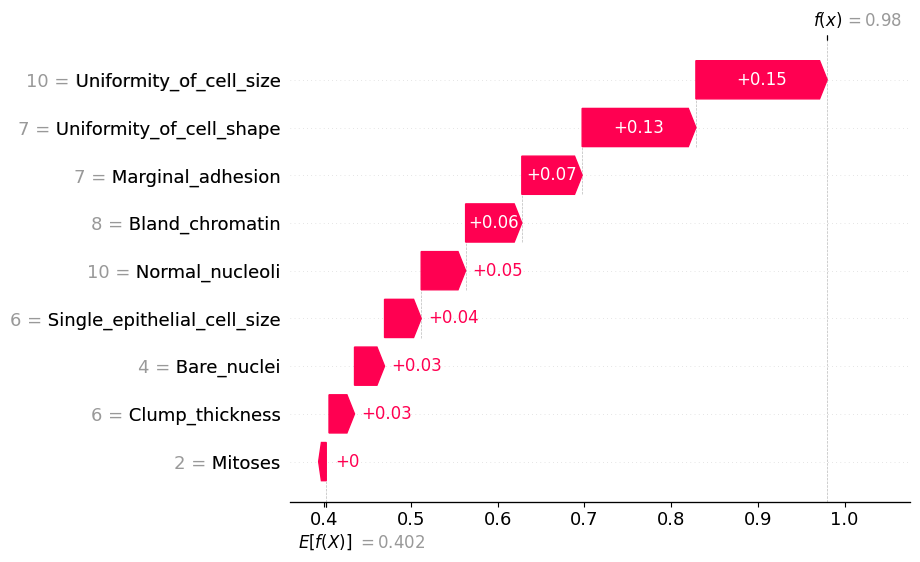

In [19]:
shap.plots.waterfall(
    overall_exp,
    max_display=len(X.columns)
)

**Cùng sample, reference = Benign training data**


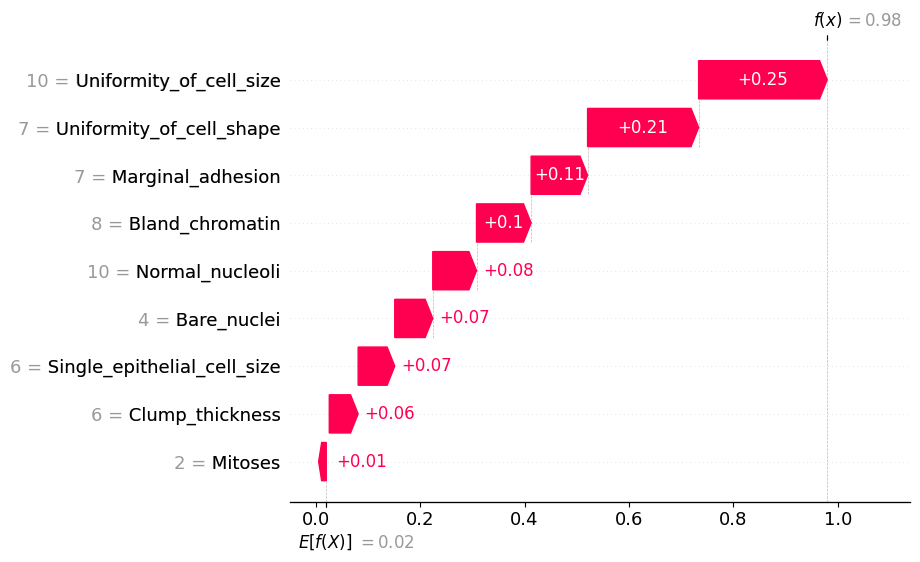

In [20]:
shap.plots.waterfall(
    benign_exp,
    max_display=len(X.columns)
)

**Giải thích kết quả**

Ở trường hợp đầu, SHAP đang trả lời:

> Tại sao prediction của sample này khoảng **0.98**, trong khi prediction trung bình của reference population khoảng **0.40**?

Các SHAP values cần giải thích quãng thay đổi:

$$
0.40 \rightarrow 0.98
$$

Ở trường hợp thứ hai, SHAP đang trả lời:

> Tại sao prediction của sample này khoảng **0.98**, trong khi một reference population chỉ gồm Benign có baseline khoảng **0.02**?

Lúc này các SHAP values phải giải thích quãng thay đổi lớn hơn:

$$
0.02 \rightarrow 0.98
$$

Vì vậy, **cùng một prediction nhưng SHAP values có thể thay đổi khi background thay đổi**.

Đây không phải là lỗi của SHAP. Câu hỏi so sánh đã thay đổi.

**Best practice**

- Chọn background phù hợp với câu hỏi muốn giải thích
- Khi trình bày SHAP values, nên nói rõ reference population là gì
- Nếu muốn so sánh nhiều sample một cách công bằng, nên dùng cùng một background


### 5.4 Limitation 3: Explanation Is Not Causality

Scatter plot có thể cho thấy một pattern như:

$$
\text{Feature value tăng}
\rightarrow
\text{SHAP value tăng}
$$

Điều này rất hữu ích để hiểu model, nhưng ta cần cẩn thận với cách diễn đạt.

Ta lấy feature có global SHAP importance cao nhất và xem lại quan hệ giữa feature value và SHAP value.


Feature used for illustration: Bare_nuclei


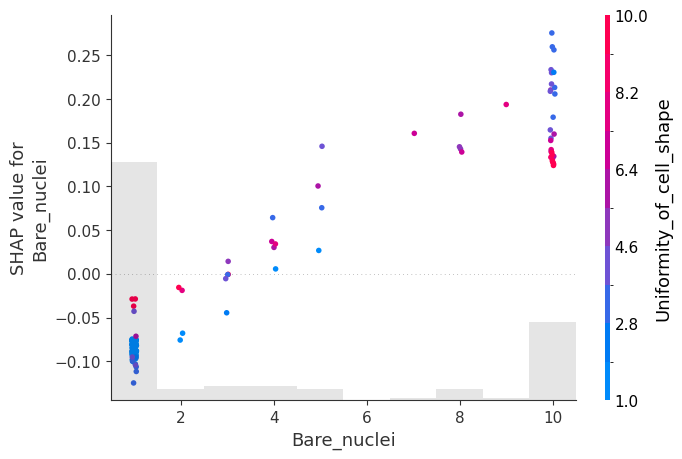

In [21]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
top_feature = X.columns[np.argmax(mean_abs_shap)]

print("Feature used for illustration:", top_feature)

shap.plots.scatter(
    shap_values[:, top_feature],
    color=shap_values
)


**Giải thích kết quả**

Nếu ta thấy các giá trị lớn của feature thường nằm ở vùng SHAP dương, ta có thể nói:

> Khi feature này có giá trị cao, **model có xu hướng tăng xác suất dự đoán mẫu thuộc về lớp Malignant**.

Đây là một kết luận hợp lý vì SHAP đang giải thích hành vi của model.

Nhưng ta **không thể** từ đó kết luận:

> Tăng giá trị feature này sẽ gây ra ung thư.

Lý do là SHAP chỉ phân tích hàm prediction mà model đã học:

$$
f(x)
$$

SHAP không thực hiện một thí nghiệm nhân quả ngoài đời thật. Một feature có thể chỉ đang liên quan với một yếu tố khác mà model sử dụng để prediction.

Vì vậy:

- **Đúng:** “Feature này làm tăng prediction của model”
- **Đúng:** “Model liên kết giá trị feature cao với nguy cơ Malignant cao hơn”
- **Không nên:** “Feature này gây ra Malignant”

**Điểm cần nhớ**

> SHAP giải thích **model behavior**, không chứng minh **causal relationship**.


## 6. Summary

Sau notebook này, bạn nên có thể:

- Phân biệt `interventional`, `tree_path_dependent` và `auto` trong TreeExplainer
- Dùng TreeSHAP để giải thích Random Forest
- Kiểm tra prediction bằng baseline và SHAP contributions
- So sánh tốc độ TreeSHAP với exact SHAP
- Đọc waterfall, bar, beeswarm và scatter
- Nhận biết ảnh hưởng của correlated features
- Hiểu vai trò của baseline
- Không nhầm SHAP explanation với quan hệ nhân quả

### References

- SHAP TreeExplainer  
  https://shap.readthedocs.io/en/latest/generated/shap.TreeExplainer.html

- SHAP ExactExplainer  
  https://shap.readthedocs.io/en/latest/generated/shap.ExactExplainer.html

- SHAP plots  
  https://shap.readthedocs.io/en/latest/api.html#plots

- UCI Breast Cancer Wisconsin Original  
  https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original